# Loading required libraries

In [72]:
library(ggplot2)
library(patchwork)
library(scales)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)
library(showtext)
library(ggbreak)
font_add("Arial", "/System/Library/Fonts/Supplemental/Arial.ttf")
showtext_auto()

# Figures and Files Setup

In [9]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_1"

# Color palettes

In [22]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)

col_male   <- "#7bbfba"
col_female <- "#2a7a74"

# Load the required data

In [11]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor...
dbl  (7): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_mo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [17]:
celltype_metadata

cell_id,Cell Center X,Cell Center Y,cell_type,cell_category,patient_ID,run,rois,exp_name,patient_exp,tumor_site,survival_time_months,age at diagnosis,sex,Therapy (local),Therapy (systemic),disease stage,is_lung,cell_category_simplified
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
378930,2480.7239,4857.791,NFC,NFC,NUT_1,145,1,Run145_ROI1,NUT_1_ROI1,Head and Neck,170,9,m,"R0 resection, RTx",VAI/PAI,NA,Head and Neck/Extrahepatic,NFC
377174,698.6422,3588.520,Tumor_cells,Tumor cells,NUT_1,145,1,Run145_ROI1,NUT_1_ROI1,Head and Neck,170,9,m,"R0 resection, RTx",VAI/PAI,NA,Head and Neck/Extrahepatic,Tumor
377175,2653.7146,3607.566,Tumor_cells,Tumor cells,NUT_1,145,1,Run145_ROI1,NUT_1_ROI1,Head and Neck,170,9,m,"R0 resection, RTx",VAI/PAI,NA,Head and Neck/Extrahepatic,Tumor
377176,3373.0640,3606.042,NFC,NFC,NUT_1,145,1,Run145_ROI1,NUT_1_ROI1,Head and Neck,170,9,m,"R0 resection, RTx",VAI/PAI,NA,Head and Neck/Extrahepatic,NFC
377177,4100.4424,3595.665,Tumor_cells,Tumor cells,NUT_1,145,1,Run145_ROI1,NUT_1_ROI1,Head and Neck,170,9,m,"R0 resection, RTx",VAI/PAI,NA,Head and Neck/Extrahepatic,Tumor
377178,2726.3611,3597.188,Tumor_cells,Tumor cells,NUT_1,145,1,Run145_ROI1,NUT_1_ROI1,Head and Neck,170,9,m,"R0 resection, RTx",VAI/PAI,NA,Head and Neck/Extrahepatic,Tumor
377179,1688.2517,3595.681,Tumor_cells,Tumor cells,NUT_1,145,1,Run145_ROI1,NUT_1_ROI1,Head and Neck,170,9,m,"R0 resection, RTx",VAI/PAI,NA,Head and Neck/Extrahepatic,Tumor
377180,1021.7406,3612.612,Tumor_cells,Tumor cells,NUT_1,145,1,Run145_ROI1,NUT_1_ROI1,Head and Neck,170,9,m,"R0 resection, RTx",VAI/PAI,NA,Head and Neck/Extrahepatic,Tumor
377173,827.8762,3594.162,Tumor_cells,Tumor cells,NUT_1,145,1,Run145_ROI1,NUT_1_ROI1,Head and Neck,170,9,m,"R0 resection, RTx",VAI/PAI,NA,Head and Neck/Extrahepatic,Tumor


In [18]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, `age at diagnosis`, sex, `Therapy (local)`, `Therapy (systemic)`, `disease stage`, survival_time_months) %>%
    rename("age" = `age at diagnosis`,
           "local_therapy" = `Therapy (local)`,
           "systemic_therapy" = `Therapy (systemic)`,
           "disease_stage" = `disease stage`) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)


In [19]:
survival_df

patient_ID,tumor_site,age,sex,local_therapy,systemic_therapy,disease_stage,survival_time_months,event,is_lung
<fct>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
NUT_1,Head and Neck,9,m,"R0 resection, RTx",VAI/PAI,NA,170,0,Head and Neck/Extrahepatic
NUT_2,Lung,6,m,RTx,"PEI, Docetaxel",NA,3,1,Lung
NUT_4,Lung,14,f,"R2 resection, RTx",Etoposid/ Carboplatin VAI/PAI,T4N3M1,4,1,Lung
NUT_5,Head and Neck,10,m,"R2 resection, RTx",VAI/PAI,T3N2M1,9,1,Head and Neck/Extrahepatic
NUT_6,Lung,23,m,RTx,Carboplatin/ Paclitaxel Docetaxel,T2N2M0,7,1,Lung
NUT_7,Lung,9,m,RTx,VAI/PAI Carboplatin/ Etoposid/ Paclitaxel BET inhibitor,T4N1M1,10,1,Lung
NUT_8,Lung,18,m,-,Cisplatin/ Etoposid VIDE,T4N0M0,4,1,Lung
NUT_9,Lung,27,m,Resektion left lung,VIDE BET-Inhibitor,pT4pN2cM0,2,1,Lung
NUT_12,Head and Neck,12,f,"RTx, Imlygic, DI-HEK5.1-L-IL2-IL12",VAI/PAI Pembrolizumab Vincristin/ Ifosfamid/ Cisplatin Carboplatin/Etoposid DI-HEK5.1-L-IL2-IL12,T4NxM1,48,1,Head and Neck/Extrahepatic


In [57]:
#age and sex pyramid

survival_df <- survival_df %>%
  mutate(
    age_group = cut(
      age,
      breaks = c(0, 10, 20, 30),
      labels = c("0-10 y", "11-20 y", "21-30 y"),
      right  = TRUE,
      include.lowest = TRUE
    ),
    sex_label = ifelse(sex == "m", "Male", "Female")
  )

#age group per sex
pyramid_df <- survival_df %>%
  count(age_group, sex_label) %>%
  mutate(
    # males left, females right
    n_plot = ifelse(sex_label == "Male", -n, n)
  )

max_n <- max(abs(pyramid_df$n_plot))
x_breaks <- seq(-ceiling(max_n), ceiling(max_n), by = 1)
x_labels <- abs(x_breaks)

p_pyramid <- ggplot(pyramid_df, aes(x = n_plot, y = age_group, fill = sex_label)) +
  geom_col(width = 0.5, color = "black", linewidth = 0.3) +
  geom_text(
    aes(label = abs(n_plot),
        hjust = ifelse(sex_label == "Male", 1.4, -0.4)),
    size = 4, color = "black"
  ) +
  scale_x_continuous(
    breaks = x_breaks,
    labels = x_labels,
    limits = c(-max_n - 1.5, max_n + 1.5)
  ) +
  scale_fill_manual(values = c("Male" = col_male, "Female" = col_female),
                    name = NULL) +
  labs(
    x     = "Number of patients",
    y     = NULL
  ) +
  geom_vline(xintercept = 0, color = "black", linewidth = 0.4) +
  theme(
    legend.position  = "bottom",
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),
    axis.text.y      = element_text(size = 10),
    axis.text.x      = element_text(size = 9)
  ) +
    theme_minimal(base_size = 13) +
    theme(
    axis.text.y = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13, colour = "black", margin = margin(t = 10)),
    axis.text.x = element_text(size = 13, colour = "black"),
    axis.title.x = element_text(size = 13, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "bottom",

  )

# Pie chart for sex ratio
sex_counts <- survival_df %>%
  count(sex_label) %>%
  mutate(pct = round(100 * n / sum(n), 1),
         label = paste0(pct, "%"))

p_pie <- ggplot(sex_counts, aes(x = "", y = n, fill = sex_label)) +
  geom_col(width = 1, color = "black", linewidth = 1) +
  coord_polar("y", start = 0) +
  geom_text(aes(label = label),
            position = position_stack(vjust = 0.5),
            color = "white", size = 10) +
  scale_fill_manual(values = c("Male" = col_male, "Female" = col_female),
                    name = NULL) +
  theme_void() +
  theme(legend.position = "none")


ggsave(filename = file.path(results_dir, "age_pyramid.pdf"),
       plot = p_pyramid, width = 5, height = 3, dpi = 300)

ggsave(filename = file.path(results_dir, "sex_pie.pdf"),
       plot = p_pie, width = 5, height = 5, dpi = 300)

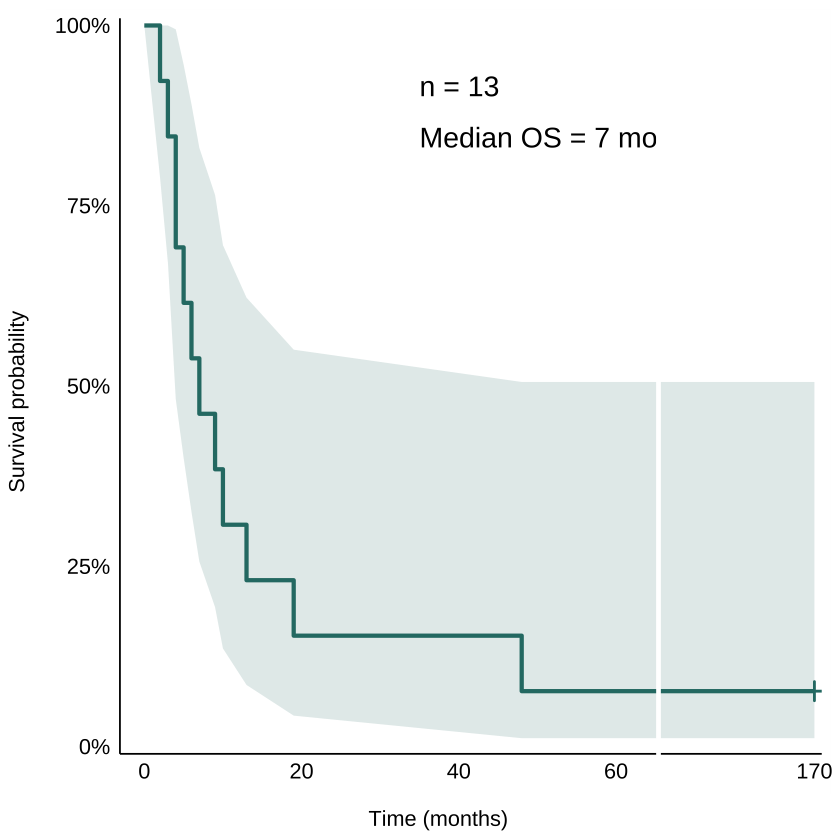

In [71]:
col_main <- "#2a7a74"

km_fit <- survfit(Surv(survival_time_months, event) ~ 1, data = survival_df)

km_df <- data.frame(
  time     = km_fit$time,
  surv     = km_fit$surv,
  upper    = km_fit$upper,
  lower    = km_fit$lower,
  n.censor = km_fit$n.censor
) %>%
  bind_rows(
    data.frame(time = 0, surv = 1, upper = 1, lower = 1, n.censor = 0),
    .
  )

censor_df <- km_df %>% filter(n.censor > 0)
med_surv  <- summary(km_fit)$table["median"]

p_km <- ggplot(km_df, aes(x = time, y = surv)) +

  geom_ribbon(aes(ymin = lower, ymax = upper),
              fill = col_main, alpha = 0.15) +

  geom_step(color = col_main, linewidth = 1.2) +

  geom_point(data = censor_df,
             aes(x = time, y = surv),
             shape = 3, size = 3, color = col_main, stroke = 1.2) +

  annotate("text", x = 35, y = 0.88,
           label = paste0("n = ", km_fit$n,
                          "\nMedian OS = ", round(med_surv, 1), " months"),
           hjust = 0, size = 6, color = "black", lineheight = 1.5) +

  scale_y_continuous(
    limits = c(0, 1),
    breaks = seq(0, 1, 0.25),
    labels = percent_format(accuracy = 1),
    expand = c(0.01, 0)
  ) +

  # X axis: dense ticks 0-60, then jump to the outlier
  scale_x_continuous(
    breaks = c(0, 20, 40, 60, max(km_df$time)),
    expand = c(0.02, 0)
  ) +

  scale_x_break(
    breaks = c(62, max(km_df$time) - 5),
    scales = 0.3,          # compress the right segment
    ticklabels = c(max(km_df$time))
  ) +

  labs(
    x        = "Time (months)",
    y        = "Survival probability"
  ) +

  theme_minimal(base_size = 13) +
  theme(
    axis.text        = element_text(size = 13, colour = "black"),
    axis.title.x     = element_text(margin = margin(t = 10)),
    axis.title.y     = element_text(margin = margin(r = 10)),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_blank(),
    axis.line.x      = element_line(colour = "black", linewidth = 0.5),
    axis.line.y      = element_line(colour = "black", linewidth = 0.5),
    axis.line.x.top = element_blank(),
    axis.text.x.top = element_blank(),
    axis.line.y.right = element_blank(),
    panel.border     = element_blank()
  )

print(p_km)